In [2]:
import h5py
import numpy as np
from pathlib import Path

from torch_em.data.sampler import MinForegroundSampler
from synapse_net.file_utils import read_mrc

### Measure actin occupancy for deepict dataset

In [3]:
LABELS_DIR = Path("/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/public/deepict/h5")
MASK_DIR = Path("/projects/extern/nhr/nhr_ni/nim00020/dir.project/sage/data/public/deepict/sample_masks")

label_paths = [p for p in LABELS_DIR.glob("*.h5")] 
mask_paths = [p for p in MASK_DIR.glob("*.mrc")]

In [4]:
def sample_patch_occupancies(labels, mask, patch_shape, n_patches=10, max_tries_per_patch=50):
    rng = np.random.default_rng()
    sampler = MinForegroundSampler(min_fraction=0.95, p_reject=1.0)

    z, y, x = labels.shape
    pz, py, px = patch_shape
    hz, hy, hx = pz//2, py//2, px//2

    # only allow patch centers where the full patch fits inside the volume
    # valid is True at valid centers
    valid = np.zeros_like(mask, dtype=bool)
    valid[hz:z-(pz-hz), hy:y-(py-hy), hx:x-(px-hx)] = True

    # centers must be valid and inside the mask for patch extraction
    candidates = np.argwhere(mask.astype(bool) & valid)
    if len(candidates) == 0:
        raise ValueError("No valid centers inside mask.")
    
    occ = np.empty(n_patches, dtype=np.float32)

    for k in range(n_patches):
        for _ in range(max_tries_per_patch):
            cz, cy, cx = candidates[rng.integers(len(candidates))]
        
            z0, z1 = cz - hz, cz - hz + pz
            y0, y1 = cy - hy, cy - hy + py
            x0, x1 = cx - hx, cx - hx + px

            label_patch = labels[z0:z1, y0:y1, x0:x1]
            mask_patch = mask[z0:z1, y0:y1, x0:x1]
            mask_patch = mask_patch.astype(np.uint8)

            # calculate occupancy (fg voxels / total voxels)
            # only accept patches with 95% masked voxels
            if sampler(label_patch, mask_patch):
                occ[k] = (label_patch == 1).mean()
                break
    
        else:
            raise RuntimeError(
                f"Failed to sample patch with 95% mask coverage after {max_tries_per_patch} tries."
            )
            
    return occ

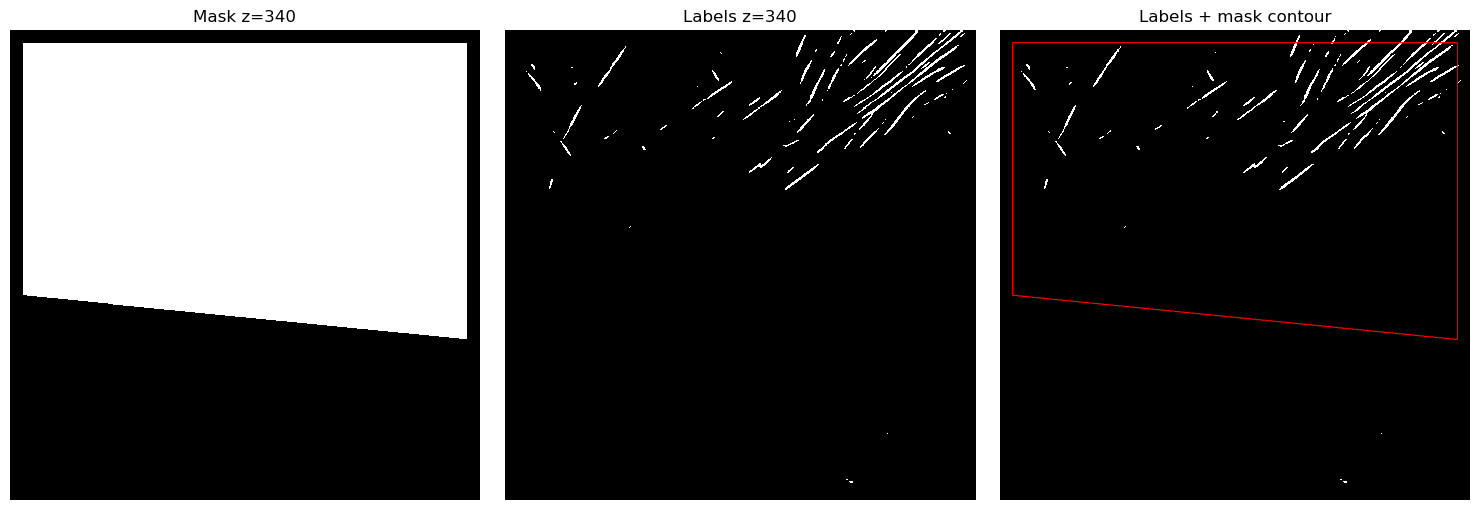

In [ ]:
# check mask alignment
import matplotlib.pyplot as plt

# `read_mrc` applies np.flip() (reflection) to axis 0, need to do the same for h5
with h5py.File(label_paths[0], "r") as f:
    labels = f["labels/actin"][:]
    labels = np.flip(labels, axis = 1)

mask = read_mrc(mask_paths[0])[0]

z = 340

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(mask[z], cmap="gray", interpolation="nearest")
ax[0].set_title(f"Mask z={z}")
ax[0].axis("off")

ax[1].imshow(labels[z], cmap="gray", interpolation="nearest")
ax[1].set_title(f"Labels z={z}")
ax[1].axis("off")

ax[2].imshow(labels[z], cmap="gray", interpolation="nearest")
ax[2].contour(mask[z].astype(bool), levels=[0.5], colors="r", linewidths=0.8)
ax[2].set_title("Labels + mask contour")
ax[2].axis("off")

plt.tight_layout()
plt.show()

In [6]:
patch_shape = (64, 384, 384)
for label_path, mask_path in zip(label_paths, mask_paths):

    with h5py.File(label_path, "r") as f:
        labels = f["labels/actin"][:]
        labels = np.flip(labels, axis = 1)

    mask = read_mrc(mask_path)[0]

    occ = sample_patch_occupancies(labels, mask, patch_shape)
    
    print(f"occupancies for {mask_path.stem}: {occ}")
    print(f"min: {occ.min()*100:.2f}%, max: {occ.max()*100:.2f}%")
    print(f"average: {occ.mean()*100:.2f}%")

occupancies for 00004: [0.06251749 0.09944132 0.08352152 0.1179001  0.07230049 0.11787754
 0.05160035 0.11697515 0.11910544 0.09989558]
min: 5.16%, max: 11.91%
average: 9.41%
occupancies for 00011: [0.04716449 0.04645453 0.02570068 0.02692604 0.02225102 0.03533628
 0.05310239 0.03754404 0.02688959 0.03595628]
min: 2.23%, max: 5.31%
average: 3.57%


### Resize deepict tomograms